In [46]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. 평균 11, 표준편차 4 > 14이상인 확률?
rv = stats.norm(11,4)
print('1. 14이상인 확률 : ' , 1-rv.cdf(14)) # 누적분포함수

rv = stats.norm(0,1)
print('1-1) 14이상인 확률 : ' , 1-rv.cdf((14-11)/4))

# 2. 평균 800, 표준편차 30 > 760 이하 확률?
rv = stats.norm(800,30)
print('2. 760 이하 확률' , rv.cdf(760)) 

# 3. 평균 70, 분산 64 > 80점이상 90점이하 확률
rv = stats.norm(70,64**0.5)
print('3. 80점이상 90점이하 확률' , rv.cdf(90) - rv.cdf(80)) 

# 4. p-value? 
# 여학생 모평균 : 600, 모편차 : 100, 표본크기 : 20, 표본 평균 : 641
# HO : 표본평균 == 모평균 H1 : !=
rv = stats.norm(0,1)
print('4. 모평균과 표본평균 같냐? : ' , 1- rv.cdf((641-600)/(100/np.sqrt(20)))) # 0.03 이 0.05보다 작으므로 같지 않다.

1. 14이상인 확률 :  0.22662735237686826
1-1) 14이상인 확률 :  0.22662735237686826
2. 760 이하 확률 0.09121121972586788
3. 80점이상 90점이하 확률 0.09944010834107919
4. 모평균과 표본평균 같냐? :  0.033358497950542465


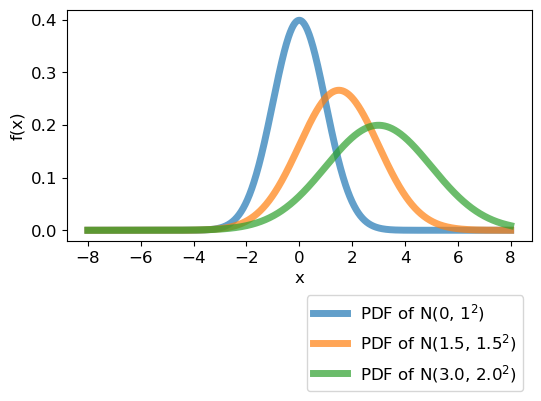

In [47]:
# 5. 정규분포
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (6, 3)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 5

mu1, sigma1 = 0.0, 1.0
mu2, sigma2 = 1.5, 1.5
mu3, sigma3 = 3.0, 2.0

x = np.linspace(-8, 8, 1000)
y1 = (1 / np.sqrt(2 * np.pi * sigma1**2)) * np.exp(-(x-mu1)**2 / (2 * sigma1**2))
y2 = (1 / np.sqrt(2 * np.pi * sigma2**2)) * np.exp(-(x-mu2)**2 / (2 * sigma2**2))
y3 = (1 / np.sqrt(2 * np.pi * sigma3**2)) * np.exp(-(x-mu3)**2 / (2 * sigma3**2))

plt.plot(x, y1, alpha=0.7, label=r'PDF of N(0, $1^2$)')
plt.plot(x, y2, alpha=0.7, label=r'PDF of N(1.5, $1.5^2$)')
plt.plot(x, y3, alpha=0.7, label=r'PDF of N(3.0, $2.0^2$)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(bbox_to_anchor=(1.0, -0.2))
plt.show()

In [71]:
### 3. 각종 확률 분표
#### Z = (X-u)/모표준편차
#### t(n-1) = (X-u) / (s / np.sqrt(n))
#### F = v(x) / v(y) = s1 / (n-1) / s2 / (m-1) > 자유도 (n-1), (m-1)

### 4. 중심경향도
#### 4-1)기하평균 : np.sqrt(ab) > 평균변화율, 평균성장률, 등의 비율을 구할 때 이용하는 수치, 시계열 자료 변동을 대표하는 값
#### 연 매출이 3000,4000,5000 > 연 평균 몇 배증가?
import numpy as np
a = (np.sqrt(((4000-3000)/3000) * ((5000-4000)/4000)))
print('기하평균 : ', a)
#### 4-2) 조화평균 : 2ab / a+b > n개의 측정치를 역수로 하여 산술평균을 구하고 이늘 다시 역수로 나타낸 평균
#### 가속현상에서 평균 속도를 구하는 것과 같이 시간 비율의 평균
#### 표본 측정치의 극단값을 줄여 균형된 자료를 만들 떄 사용
#### 갈 때 4km, 올 때 5km > 왕복평균속도는?
print('조화평균 : ', (2*4*5)/(4+5))
#### 4-2) 산술 >= 기하 >= 조화

#### 5. 변동계수 = cv = 표준편차 / 평균
#### 관찰치의 산포 정도를 상대적으로 비교할 때 이용 > 평균의 차이가 큰 두 집단의 산포를 비교할 때
#### 단위가 다른 서로 다른 두 집단 자료의 산포를 비교할 때 이용
#### 변동계수가 작을 수록 평균에 더 밀집

#### 6. 이항분포
#### 업체 수 : 50, 성공확률 0.1, 성공횟수 : 2

from math import factorial, exp

b = (factorial(50-1) / ((factorial(2) * factorial(49-2)))) * (0.1**2) * ((1-0.1)**(49-2))
print('이항분포 : ', b)

#### 7. 포아쏭분포
#### 일주일에 휴대폰 놓고 나간 횟수 3회, 일주일에 1회이하? + 4~5회?
one = (3 ** 1) * exp(-3) / factorial(1)
zero = (3 ** 0) * exp(-3) / factorial(0)
four = (3 ** 4) * exp(-3) / factorial(4)
five = (3 ** 5) * exp(-3) / factorial(5)
print('포아쏭분포 : ', one, zero, one+zero, four, five, four + five)

#### 8. 신뢰구간
#### 데이터개수 : 12, 평균 166, 표준편차 6.6469, 표준오차 1.9188 / np.sqrt(12) = 1.91, 95% 신뢰도
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h


h = 1.9188 * stats.t.ppf((1+0.95) / 2., 11 )
print(h)
print('신뢰구간 : ', 166 - h, 166 + h)

#### 9. 적절한 표본개수  = ((z의 1/2 값 * 모표준편차)/(허용오차))**2
from scipy.stats import t
x = [52,50,62,75,26,45,62,35,57,14]
moe = 5 # 오차한계
std = np.std(x) # 표준편차
print('표준편차 : ', std)
print('유의수준 : 0.05, 자유도 : 9의 t값 : ',  t.ppf(q = 0.05, df = 9))
print('적절한 표본개수 : ', (t.ppf(q = 0.05, df = 9)*std / 5) ** 2) # ppf 누적분포함수의 역함수

import numpy as np
from scipy import stats as st

#### 10. 모분산 신뢰구간
xs = np.array([66, 78, 18, 96, 85, 63, 73, 83, 65, 80, 75, 56, 95, 77, 66])
n = len(xs) 
s2 = xs.var(ddof=1)  # 표본분산: 350.209
x_left = st.chi2.ppf(0.025, df=n-1) # 5.629
x_right = st.chi2.ppf(0.975, df=n-1) # 26.119

area = ((n - 1) * s2 / x_left, (n - 1) * s2 / x_right)
print('모분산 신뢰구간 : ', area)


기하평균 :  0.28867513459481287
조화평균 :  4.444444444444445
이항분포 :  0.08313908976417642
포아쏭분포 :  0.14936120510359183 0.049787068367863944 0.19914827347145578 0.16803135574154082 0.10081881344492448 0.2688501691864653
4.223250325167163
신뢰구간 :  161.77674967483284 170.22325032516716
표준편차 :  17.434448657758008
유의수준 : 0.05, 자유도 : 9의 t값 :  -1.8331129326536337
적절한 표본개수 :  40.85590828532381
모분산 신뢰구간 :  (871.0555894140166, 187.71557433626796)
